# Training of the gabor filters

In [1]:
# Training was done by using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Imported libraries
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,random_split, DataLoader

# Data loading and splitting

In [3]:
# Pytorch dataset for supervised learning.
# Loads image with masks of the finger veins (ground truth).
class SupervisedDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = [
            f for f in os.listdir(image_dir)
            if os.path.exists(os.path.join(mask_dir, f))]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path = os.path.join(self.image_dir, fname)
        mask_path = os.path.join(self.mask_dir, fname)

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0

        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.from_numpy(image), torch.from_numpy(mask)

In [4]:
# Pytorch dataset for unsupervised learning.
class UnsupervisedDataset(Dataset):
    def __init__(self, image_dir):
        self.image_dir = image_dir
        self.filenames = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.filenames[idx])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        img = torch.from_numpy(img).unsqueeze(0).float()

        return img

In [5]:
# Root path to dataset
colab_path = "/content/drive/MyDrive/Finger vein enhancement/db_zvlast"

# Paths
label_img_dir = f"{colab_path}/mmc_label/image"
label_mask_dir = f"{colab_path}/mmc_label/mask"
unlabel_img_dir = f"{colab_path}/mmc"
test_img_dir = f"{colab_path}/mmc_test"

# Supervised data
labeled_dataset = SupervisedDataset(label_img_dir, label_mask_dir)

# Split of data
train_size = int(0.99 * len(labeled_dataset))
val_size = len(labeled_dataset) - train_size
train_ds, val_ds = random_split(labeled_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False)

# Unsupervised data
unlabel_dataset = UnsupervisedDataset(unlabel_img_dir)
unlabel_loader = DataLoader(unlabel_dataset, batch_size=4, shuffle=True)

# Final evaluation data
test_dataset = UnsupervisedDataset(test_img_dir)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

# Gabor filters connected to convolutional neural networks

In [6]:
# Convolutional neural network with fixed gabor filters.
# Mainly used to find the parameters with the best results
# In this architecture 6 gabor filters were used
class FixedGaborCNN(nn.Module):
    def __init__(self, num_gabor=6, gabor_ksize=61):
        super().__init__()
        # Only trainable Gabor convolution layer
        self.gabor = nn.Conv2d(1, num_gabor, kernel_size=gabor_ksize, padding=gabor_ksize//2, bias=False)

        # Fixed gabor parameters
        self._init_gabor()

        # Feature extractor conv layers
        self.conv1 = nn.Conv2d(num_gabor, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.out_conv = nn.Conv2d(32, 1, kernel_size=1)

    def _init_gabor(self):
        # Initialization of gabor parameters
        orientations = [0, 18, 65, 90, 115, 160]
        ksize = self.gabor.kernel_size[0]
        sigma, lambd, gamma, psi = 5.0, 16.0, 1, 0.0
        kernels = []
        for angle in orientations:
            theta = np.deg2rad(angle)
            kernel = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, psi, ktype=cv2.CV_32F)
            kernels.append(kernel)
        kernels = np.stack(kernels, axis=0)
        kernels = torch.from_numpy(kernels).unsqueeze(1).float()
        with torch.no_grad():
            self.gabor.weight[:len(kernels)] = kernels

    def forward(self, x):
        gabor_out = self.gabor(x)
        x1 = F.relu(self.conv1(gabor_out))
        x2 = F.relu(self.conv2(x1))
        x3 = F.relu(self.conv3(x2))
        out = self.out_conv(x3 + x1)
        return out

In [ ]:
# Convolutional neural network with adaptive gabor filters.
# Two different configuration were compared, with 6 or 10 gabor filters
class AdaptiveGaborCNN(nn.Module):
    def __init__(self, num_gabor=10, gabor_ksize=61):
        super().__init__()
        self.num_gabor = num_gabor
        self.gabor_ksize = gabor_ksize

        # Learnable gabor filter parameters
        self.sigma = nn.Parameter(torch.ones(num_gabor) * 5.0)
        # Orientaions for 6 gabor filters configuration - [0, 18, 65, 90, 115, 160]
        self.theta = nn.Parameter(torch.tensor([0, 18, 36, 54, 72, 90, 108, 126, 144, 162]) * math.pi / 180)
        self.lambd = nn.Parameter(torch.ones(num_gabor) * 16.0)
        self.gamma = nn.Parameter(torch.ones(num_gabor) * 1.0)
        self.psi = nn.Parameter(torch.zeros(num_gabor))

        # Feature extractor conv layers
        self.conv1 = nn.Conv2d(num_gabor, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.out_conv = nn.Conv2d(32, 1, kernel_size=1)

    def _create_gabor_bank(self):
        # For adaptive gabor filter was needed to make the formulas manually - with help of GPT from fixed parameters
        device = self.sigma.device
        ksize = self.gabor_ksize

        # Create coordinate grid centered at 0
        coords = torch.arange(ksize, device=device).float() - (ksize - 1) / 2
        y, x = torch.meshgrid(coords, coords, indexing='ij')

        # Add filter dimension for broadcasting
        x = x.unsqueeze(0)
        y = y.unsqueeze(0)

        # Rotate coordinate system for each theta
        x_theta = x * torch.cos(self.theta).unsqueeze(-1).unsqueeze(-1) + \
                  y * torch.sin(self.theta).unsqueeze(-1).unsqueeze(-1)
        y_theta = -x * torch.sin(self.theta).unsqueeze(-1).unsqueeze(-1) + \
                   y * torch.cos(self.theta).unsqueeze(-1).unsqueeze(-1)

        # Compute Gaussian envelope
        gb = torch.exp(-0.5 * ((x_theta ** 2 + (self.gamma.unsqueeze(-1).unsqueeze(-1) * y_theta) ** 2) /
                               (self.sigma.unsqueeze(-1).unsqueeze(-1) ** 2)))

        # Apply cosine modulation (Gabor function)
        gb = gb * torch.cos(2 * math.pi * x_theta / self.lambd.unsqueeze(-1).unsqueeze(-1) +
                            self.psi.unsqueeze(-1).unsqueeze(-1))

        return gb.unsqueeze(1)

    def forward(self, x):
        gabor_kernels = self._create_gabor_bank()
        gabor_out = F.conv2d(x, gabor_kernels, padding=self.gabor_ksize // 2)
        x1 = F.relu(self.conv1(gabor_out))
        x2 = F.relu(self.conv2(x1))
        x3 = F.relu(self.conv3(x2))
        return self.out_conv(x3 + x1)

# Training of CNNs

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = AdaptiveGaborCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss() # Supervised loss

In [9]:
# Edge-Preserving / Gradient Consistency Loss - unsupervised loss
def edge_preserving_loss(preds, imgs):
    # Sobel gradients for both image and prediction
    sobel_x = torch.tensor([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]], dtype=torch.float32, device=preds.device).unsqueeze(0).unsqueeze(0)
    sobel_y = sobel_x.transpose(2, 3)

    def grad_map(x):
        gx = F.conv2d(x, sobel_x, padding=1)
        gy = F.conv2d(x, sobel_y, padding=1)
        return torch.sqrt(gx ** 2 + gy ** 2 + 1e-6)

    grad_pred = grad_map(preds)
    grad_img = grad_map(imgs)

    return torch.mean(torch.abs(grad_pred - grad_img))

In [14]:
# The training loop
epochs = 10

for epoch in range(epochs):
    model.train()

    # Supervised step
    for i, (imgs, masks) in enumerate(train_loader):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss_sup = criterion(preds, masks)

        optimizer.zero_grad()
        loss_sup.backward()
        optimizer.step()

        if i % 20 == 0:
            print(f"Epoch {epoch} | Supervised batch {i} | Loss: {loss_sup.item():.4f}")

    # Unsupervised step
    for i, imgs in enumerate(unlabel_loader):
        imgs = imgs.to(device)
        preds = model(imgs)

        loss_unsup = edge_preserving_loss(preds, imgs)

        optimizer.zero_grad()
        loss_unsup.backward()
        optimizer.step()

        if i % 20 == 0:
            print(f"Epoch {epoch} | Unsupervised batch {i} | Edge loss: {loss_unsup.item():.4f}")
        # After more data the model started to overfit
        if i % 200 == 0 and i != 0:
            break

In [ ]:
# Save of the trained model
save_path = "/content/drive/MyDrive/Finger vein enhancement/db_zvlast/mmc_model/gabor_model.pth"
torch.save(model.state_dict(), save_path)

In [12]:
# Load of the trained model
load_path = "/content/drive/MyDrive/Finger vein enhancement/db_zvlast/mmc_model/gabor_model.pth"
model.load_state_dict(torch.load(load_path))

<All keys matched successfully>

# Evaluation

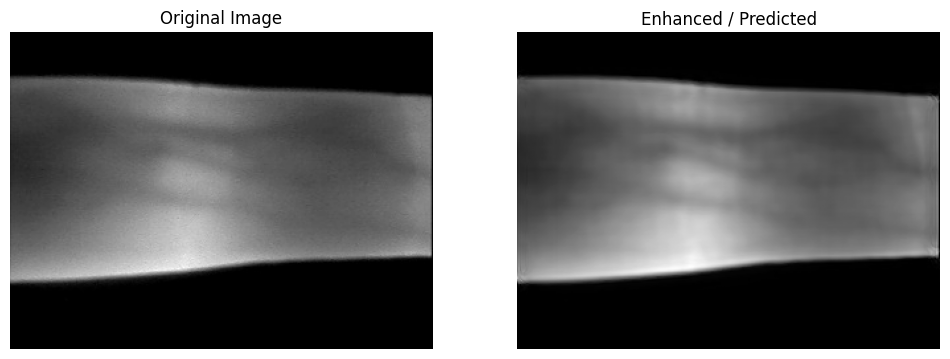

In [13]:
# Visualization of model on 1 image
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.eval()

# Pick one test image
img_path = '/content/drive/MyDrive/Finger vein enhancement/db_zvlast/mmc_test/003_r_28.jpg'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Convert to torch tensor
input_tensor = torch.from_numpy(img_norm).unsqueeze(0).unsqueeze(0).float().to(device)

# Forward pass
with torch.no_grad():
    pred = model(input_tensor)

out_img = pred.squeeze().cpu().numpy()
out_img = np.clip(out_img, 0, 255).astype(np.uint8)

# Display
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Enhanced / Predicted")
plt.imshow(out_img, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
# Evaluation of all test set
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.eval()

source_folder = 'mmc_test/'
output_folder = 'mmc_results/'
path = "/content/drive/MyDrive/Finger vein enhancement/db_zvlast/"

test_image_paths = [
    path + source_folder + f
    for f in sorted(os.listdir(path + source_folder))
    if f.endswith('.jpg')
]

# Process test images
for idx, img_path in enumerate(test_image_paths):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Convert to torch tensor
    input_tensor = torch.from_numpy(img_norm).unsqueeze(0).unsqueeze(0).float().to(device)

    # Forward pass
    with torch.no_grad():
        pred = model(input_tensor)

    # Convert output to image
    out_img = pred.squeeze().cpu().numpy()
    out_img = np.clip(out_img, 0, 255).astype(np.uint8)

    # Save image
    image_filename = f"test_image_{idx}_pred.jpg"
    save_path = os.path.join(path+output_folder, image_filename)
    cv2.imwrite(save_path, out_img)

print("Processing complete!")

Processing complete!
